In [ ]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import TimeSeries, dRSA, print_wise, get_lagplot
from general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data
from image_processing.gaze_dep_models import save_pixelwise_luminance


In [134]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    mod_fs = 23.976
    sq_side = 250
    downsampled_sq_size = 50
    sensors_group = 'occ'
    model_name = "OFdir"
    time_points = 600
    pseudotrials_n = 100
    max_lag = 200
    iterations_n = 100
    repetition = 0
    RDM_metric = "cosine"
cfg = Cfg()

In [8]:
def load_hp_meg_data(paths: dict[str: str], sub_num: int, run: int, sensors_group: str, fs: float):
    file_path = f"{paths['data_path']}/data/sub{sub_num:03d}/preprocessed_hp05/sub{sub_num:03d}_{sensors_group}_{fs}Hz_MNN0_badmuscle0_badlowfreq1_badsegint1_badcomp2.mat"    
    data = loadmat(file_path)
    labels = [str(x[0]) for x in data['label'].flatten()]
    data_neural = data['data_final'][run-1][0]
    data_neural = TimeSeries(data_neural, fs)
    return data_neural, labels
# EOF

In [127]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(tot_rsa)
    max_lag = max_lag
    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks+= max_lag
    ax[1].plot(get_lagplot(tot_rsa, max_lag=max_lag));
    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1);
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    fig.suptitle(title, fontsize=20)
    plt.tight_layout()

In [113]:
mod = []
len_mod = []
for i_run in range(1,4):
    model_filename = save_pixelwise_luminance(paths, cfg.model_name, cfg.sub_num, i_run + 3*cfg.repetition, cfg.mod_fs, cfg.sq_side, *(cfg.downsampled_sq_size,))
    with h5py.File(model_filename, "r") as f:
        run_mod = f['vecrep'][:]
    # end with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(run_mod, cfg.mod_fs)
    run_mod.resample(cfg.neu_fs)
    len_mod.append(len(run_mod)) 
    mod.append(run_mod.get_array())
# end for i_run in range(1,4):
mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)

In [114]:
neu_hp = []
for i_run in range(1,4):
    run_neu_hp, labels = load_hp_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    neu_hp.append(run_neu_hp[:len_mod[i_run-1]])
# end for i_run in range(1,4):
neu_hp = TimeSeries(np.concatenate(neu_hp, axis=1), cfg.neu_fs)

In [115]:
neu = []
for i_run in range(1,4):
    run_neu, labels = load_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    neu.append(run_neu[:len_mod[i_run-1]])
# end for i_run in range(1,4):
neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)

In [116]:

def subsampling_II(neu_trials, mod_trials, neu_metric, mod_metric, k=1):
    drsa_obj_corr = dynInformationImbalance(neu_metric, mod_metric, k=k)
    drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
    drsa_obj_corr.compute_both_distance_ranks_timeseries()
    rsa_corr = drsa_obj_corr.compute_dynII('B2A')
    return rsa_corr
# EOF

def subsampling_RSA(neu_trials, mod_trials, neu_metric, mod_metric,):
    drsa_obj_corr = dRSA(neu_metric, model_RDM_metric=mod_metric)
    drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
    rsa_corr = drsa_obj_corr.compute_dRSA()
    return rsa_corr
# EOF

def subsampling(neu, mod, time_points, iteration_n, pseudotrials_n, func, *args, **kwargs):
    tot_rsa = np.zeros((time_points, time_points))
    for i_iter in range(iteration_n):
        print_wise(f"starting iteration {i_iter} of {iteration_n-1} ")
        neu_trials = []
        mod_trials = []
        pseudotrials_idx = random.sample(range(len(neu)- time_points), pseudotrials_n )
        for n in pseudotrials_idx:
            neu_trials.append(neu.get_array()[:,n:n+time_points])
            mod_trials.append(mod.get_array()[:,n:n+time_points])
        neu_trials = TimeSeries(np.stack(neu_trials, axis=2), cfg.neu_fs)
        mod_trials = TimeSeries(np.stack(mod_trials, axis=2), cfg.neu_fs)
        # drsa_obj_corr = dRSA("correlation")
        rsa_corr = func(neu_trials, mod_trials, *args, **kwargs)    
        tot_rsa += rsa_corr
    tot_rsa = tot_rsa/iteration_n
    return tot_rsa
# EOF

In [135]:
tot_rsa = subsampling(neu, mod, cfg.time_points, cfg.iterations_n, cfg.pseudotrials_n, subsampling_RSA, *(cfg.RDM_metric, cfg.RDM_metric),)

09:54:05 - starting iteration 0 of 99 
09:54:08 - starting iteration 1 of 99 
09:54:10 - starting iteration 2 of 99 
09:54:12 - starting iteration 3 of 99 
09:54:14 - starting iteration 4 of 99 
09:54:16 - starting iteration 5 of 99 
09:54:18 - starting iteration 6 of 99 
09:54:19 - starting iteration 7 of 99 
09:54:21 - starting iteration 8 of 99 
09:54:23 - starting iteration 9 of 99 
09:54:25 - starting iteration 10 of 99 
09:54:27 - starting iteration 11 of 99 
09:54:29 - starting iteration 12 of 99 
09:54:31 - starting iteration 13 of 99 
09:54:33 - starting iteration 14 of 99 
09:54:35 - starting iteration 15 of 99 
09:54:37 - starting iteration 16 of 99 
09:54:39 - starting iteration 17 of 99 
09:54:41 - starting iteration 18 of 99 
09:54:42 - starting iteration 19 of 99 
09:54:44 - starting iteration 20 of 99 
09:54:46 - starting iteration 21 of 99 
09:54:48 - starting iteration 22 of 99 
09:54:50 - starting iteration 23 of 99 
09:54:52 - starting iteration 24 of 99 
09:54:54 -

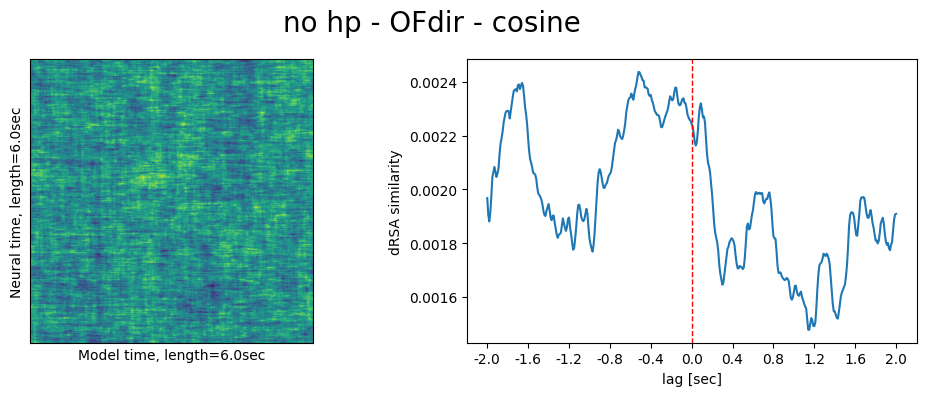

In [136]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"no hp - {cfg.model_name} - {cfg.RDM_metric}", tick_step=40)

In [125]:
tot_rsa_hp = subsampling(neu_hp, mod, cfg.time_points, cfg.iterations_n, cfg.pseudotrials_n, subsampling_RSA, *("correlation", "correlation"),)

09:24:29 - starting iteration 0 of 99 
09:24:31 - starting iteration 1 of 99 
09:24:33 - starting iteration 2 of 99 
09:24:35 - starting iteration 3 of 99 
09:24:37 - starting iteration 4 of 99 
09:24:39 - starting iteration 5 of 99 
09:24:41 - starting iteration 6 of 99 
09:24:43 - starting iteration 7 of 99 
09:24:45 - starting iteration 8 of 99 
09:24:47 - starting iteration 9 of 99 
09:24:50 - starting iteration 10 of 99 
09:24:52 - starting iteration 11 of 99 
09:24:54 - starting iteration 12 of 99 
09:24:56 - starting iteration 13 of 99 
09:24:59 - starting iteration 14 of 99 
09:25:01 - starting iteration 15 of 99 
09:25:03 - starting iteration 16 of 99 
09:25:05 - starting iteration 17 of 99 
09:25:07 - starting iteration 18 of 99 
09:25:10 - starting iteration 19 of 99 
09:25:12 - starting iteration 20 of 99 
09:25:14 - starting iteration 21 of 99 
09:25:16 - starting iteration 22 of 99 
09:25:18 - starting iteration 23 of 99 
09:25:20 - starting iteration 24 of 99 
09:25:22 -

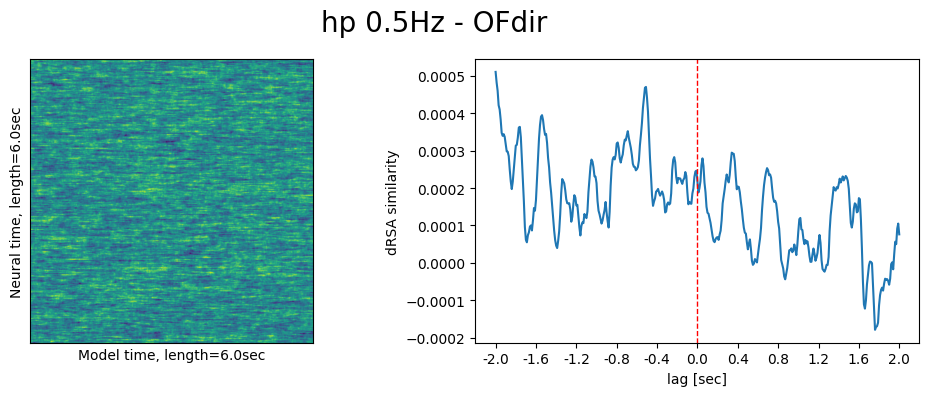

In [130]:
plot_rsa(tot_rsa_hp, cfg.neu_fs, cfg.max_lag, f"hp 0.5Hz - {cfg.model_name}", tick_step=40)

In [15]:
drsa_obj_corr = dRSA("correlation")
drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_corr = drsa_obj_corr.compute_dRSA()
drsa_obj_euc = dRSA("euclidean")
drsa_obj_euc.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_euc = drsa_obj_euc.compute_dRSA()
drsa_obj_cos = dRSA("cosine_cnt")
drsa_obj_cos.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_cos = drsa_obj_cos.compute_dRSA()

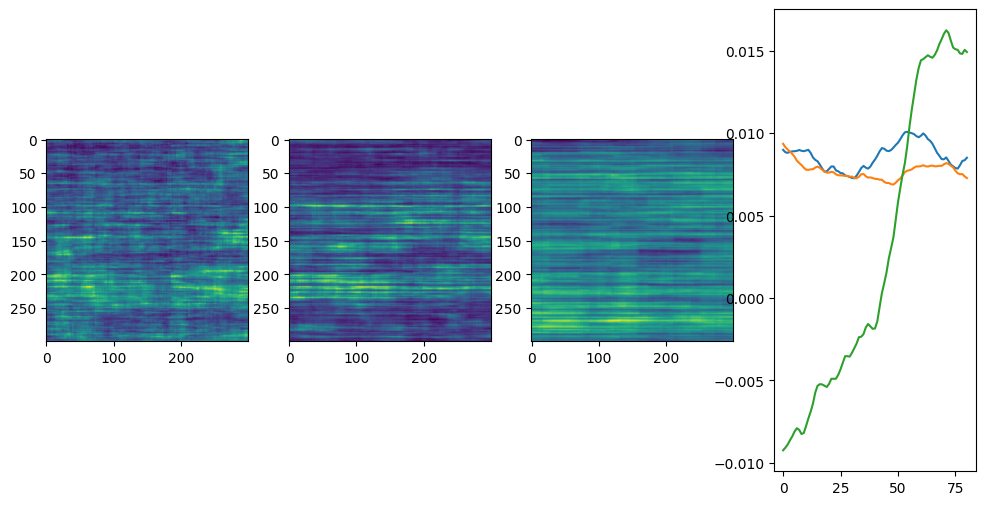

In [16]:
from general_utils.utils import get_lagplot
fig, ax = plt.subplots(1,4, figsize=(12,6))
ax[0].imshow(rsa_corr)
ax[1].imshow(rsa_cos)
ax[2].imshow(rsa_euc)
# fig.colorbar()
ax[3].plot(get_lagplot(rsa_corr, max_lag=40))
ax[3].plot(get_lagplot(rsa_cos, max_lag=40))
ax[3].plot(get_lagplot(rsa_euc, max_lag=40))

In [ ]:
drsa_obj_corr = dRSA("correlation")
drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_corr = drsa_obj_corr.compute_dRSA()
drsa_obj_euc = dRSA("euclidean")
drsa_obj_euc.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_euc = drsa_obj_euc.compute_dRSA()
drsa_obj_cos = dRSA("cosine_cnt")
drsa_obj_cos.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_cos = drsa_obj_cos.compute_dRSA()

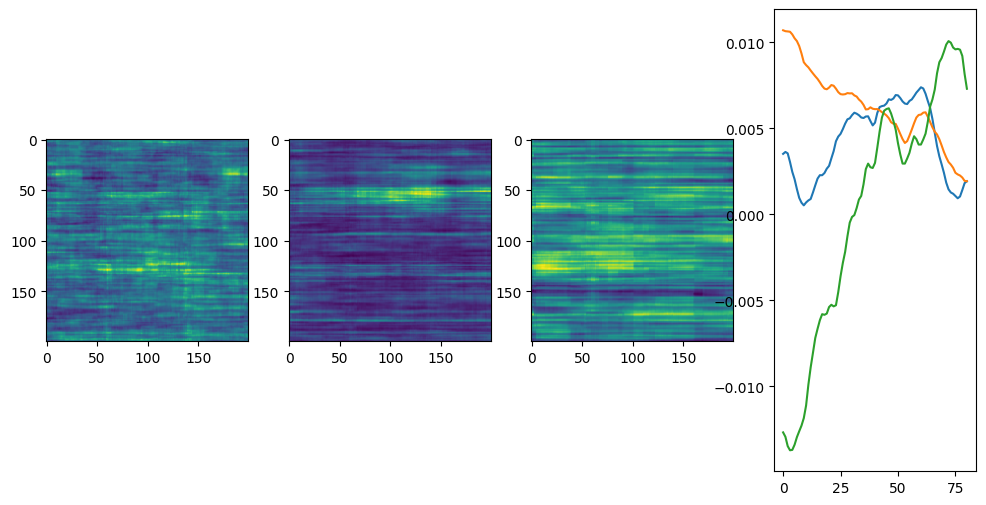

In [ ]:
from general_utils.utils import get_lagplot
fig, ax = plt.subplots(1,4, figsize=(12,6))
ax[0].imshow(rsa_corr)
ax[1].imshow(rsa_cos)
ax[2].imshow(rsa_euc)
# fig.colorbar()
ax[3].plot(get_lagplot(rsa_corr, max_lag=40))
ax[3].plot(get_lagplot(rsa_cos, max_lag=40))
ax[3].plot(get_lagplot(rsa_euc, max_lag=40))

In [ ]:
drsa_obj_corr = dRSA("correlation")
drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_corr = drsa_obj_corr.compute_dRSA()
drsa_obj_euc = dRSA("euclidean")
drsa_obj_euc.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_euc = drsa_obj_euc.compute_dRSA()
drsa_obj_cos = dRSA("cosine_cnt")
drsa_obj_cos.compute_both_RDM_timeseries(neu_trials, mod_trials)
rsa_cos = drsa_obj_cos.compute_dRSA()

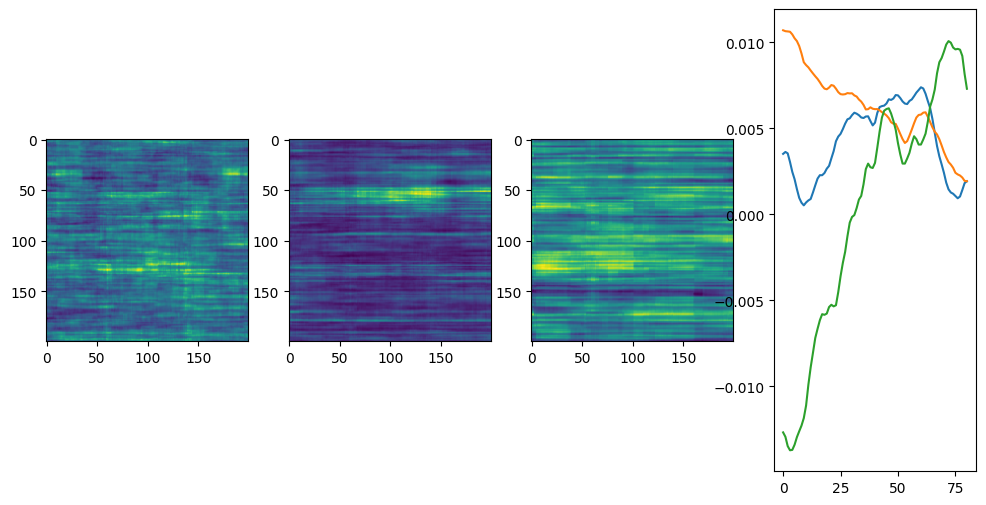

In [ ]:
from general_utils.utils import get_lagplot
fig, ax = plt.subplots(1,4, figsize=(12,6))
ax[0].imshow(rsa_corr)
ax[1].imshow(rsa_cos)
ax[2].imshow(rsa_euc)
# fig.colorbar()
ax[3].plot(get_lagplot(rsa_corr, max_lag=40))
ax[3].plot(get_lagplot(rsa_cos, max_lag=40))
ax[3].plot(get_lagplot(rsa_euc, max_lag=40))